# MODULE 5 — Visualisation des Données

Un graphique vaut mille mots ! En data science, la visualisation permet de comprendre rapidement les données.

Dans ce module, tu vas apprendre à créer des graphiques avec deux bibliothèques :
- **Matplotlib** : la bibliothèque de base pour les graphiques
- **Seaborn** : construite sur Matplotlib, avec des graphiques plus beaux et plus faciles

Dans ce module, tu vas créer :
- Des graphiques en barres (bar chart)
- Des courbes (line chart)
- Des histogrammes
- Des camemberts (pie chart)
- Des boxplots
- Des heatmaps (cartes de chaleur)

In [1]:
# %matplotlib inline dit a Jupyter d'afficher les graphiques DANS le notebook
%matplotlib inline

import matplotlib.pyplot as plt  # bibliotheque principale de graphiques
import seaborn as sns             # bibliotheque de graphiques avances
import pandas as pd               # pour manipuler les donnees
import numpy as np                # pour les calculs
import os                         # pour tester l'existence de fichiers

# On configure le style des graphiques Seaborn
sns.set_theme(style="whitegrid")  # fond blanc avec grille
print("Bibliotheques de visualisation chargees !")

Bibliotheques de visualisation chargees !


### Chargement du dataset

On charge le fichier CSV nettoyé produit par le module 4.
Si ce fichier n'existe pas, on utilise le fichier brut avec un nettoyage rapide.

In [2]:
# On charge le dataset nettoye (produit par le module 4)
if os.path.exists("ventes_koryxa_propre.csv"):
    df = pd.read_csv("ventes_koryxa_propre.csv", encoding="utf-8")
    print("Dataset propre charge !")
else:
    df = pd.read_csv("ventes_koryxa.csv", encoding="utf-8")
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["mois"] = df["date"].dt.month
    print("Dataset brut charge avec nettoyage rapide !")

print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")

Dataset propre charge !
Dimensions : 100 lignes x 15 colonnes


---
## PARTIE 1 — Graphique en Barres (Bar Chart)

### Qu'est-ce qu'un bar chart ?

Le **graphique en barres** est ideal pour **comparer des categories** entre elles.

**Exemple de vie reelle :** un magasin veut savoir quel rayon vend le plus.

Chaque barre represente une categorie, et la hauteur de la barre = la valeur.

**Quand l'utiliser ?** Quand on veut comparer des valeurs entre differentes categories.

### Etape 1 : on prepare les donnees avec groupby

In [3]:
# On calcule le chiffre d'affaires total par categorie de produit
# groupby regroupe les lignes par categorie
# sum() additionne les totaux de vente
ventes_categorie = df.groupby("categorie")["total"].sum().sort_values(ascending=False)
print(ventes_categorie)

categorie
Périphérique    256865.56
Informatique     95560.60
Stockage         27349.17
Audio            21030.96
Accessoire       16455.77
Name: total, dtype: float64


### Etape 2 : on trace le graphique avec ax.bar() + plt.show()

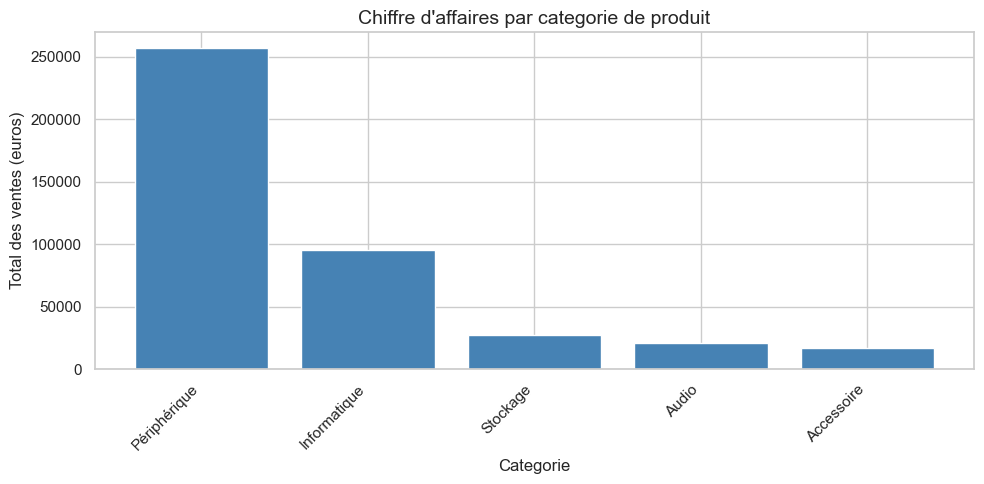

In [4]:
# On cree le graphique en barres
fig, ax = plt.subplots(figsize=(10, 5))   # on cree la feuille et le cadre

# ax.bar() trace les barres
ax.bar(ventes_categorie.index, ventes_categorie.values, color="steelblue")
ax.set_title("Chiffre d'affaires par categorie de produit", fontsize=14)  # titre
ax.set_xlabel("Categorie")                # axe X
ax.set_ylabel("Total des ventes (euros)") # axe Y
plt.xticks(rotation=45, ha="right")       # incline les etiquettes

plt.tight_layout()   # ajuste les marges
plt.show()           # affiche le graphique dans le notebook

### Analyse du bar chart

Ce graphique montre le chiffre d'affaires total de chaque categorie de produits Koryxa.

On voit clairement que la categorie **Peripherique** domine largement avec plus de 60% du CA total.
La categorie **Informatique** arrive en deuxieme position avec environ 23% du CA.
Les trois autres categories (Stockage, Accessoire, Audio) se partagent les 17% restants.
Cette information est precieuse : Koryxa devrait concentrer ses efforts commerciaux et son stock
sur les peripheriques pour maximiser les revenus.

---
## PARTIE 2 — Courbe (Line Chart)

### Qu'est-ce qu'un line chart ?

La **courbe** est ideale pour montrer l'**evolution dans le temps**.

**Exemple de vie reelle :** la meteo montre la temperature jour par jour avec une courbe.

Les points sont relies par une ligne pour montrer la tendance.

**Quand l'utiliser ?** Quand les donnees sont ordonnees dans le temps (mois, annees, jours).

### Etape 1 : on calcule les ventes par mois

In [5]:
# On convertit la colonne mois en entier et on somme les ventes par mois
# dropna() supprime d abord les valeurs manquantes avant la conversion
df_mois = df.dropna(subset=["mois"]).copy()          # on enleve les lignes sans mois
df_mois["mois"] = df_mois["mois"].astype(int)        # convertit float en entier
ventes_mensuelles = df_mois.groupby("mois")["total"].sum().sort_index()  # somme par mois
print(ventes_mensuelles)

mois
1      27918.25
2      22199.73
3      28909.92
4      14399.38
5      83206.66
6      38242.61
7      26392.90
8       4475.67
9      20436.57
10     13427.44
11    106618.93
12     14042.99
Name: total, dtype: float64


### Etape 2 : on trace la courbe avec ax.plot() + plt.show()

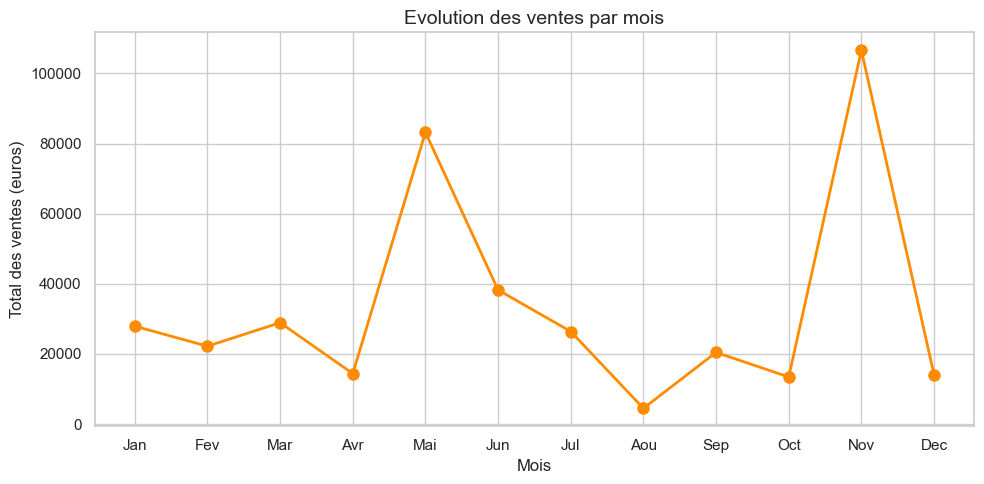

In [6]:
# On cree la courbe d'evolution des ventes mois par mois
fig, ax = plt.subplots(figsize=(10, 5))

# ax.plot() trace la courbe, marker="o" ajoute des points sur chaque mois
ax.plot(ventes_mensuelles.index, ventes_mensuelles.values,
        marker="o", color="darkorange", linewidth=2, markersize=8)

ax.set_title("Evolution des ventes par mois", fontsize=14)  # titre
ax.set_xlabel("Mois")                                       # axe X
ax.set_ylabel("Total des ventes (euros)")                   # axe Y

noms_mois = ["Jan","Fev","Mar","Avr","Mai","Jun","Jul","Aou","Sep","Oct","Nov","Dec"]
ax.set_xticks(range(1, 13))       # 12 positions sur l'axe X
ax.set_xticklabels(noms_mois)     # noms des mois au lieu des numeros

plt.tight_layout()
plt.show()

### Analyse de la courbe mensuelle

Cette courbe montre comment les ventes evoluent au fil des mois.

On peut reperer des **pics** (mois ou les ventes sont fortes) et des **creux** (mois plus calmes).
**Novembre** ressort comme le mois le plus fort avec plus de 100 000 euros de CA
— probablement l'effet Black Friday et les achats de fin d'annee.
**Mai** est egalement tres actif avec plus de 80 000 euros.
Ces informations aident a planifier les stocks et les campagnes marketing aux bonnes periodes.

---
## PARTIE 3 — Histogramme

### Qu'est-ce qu'un histogramme ?

L'**histogramme** montre la **distribution** d'une variable numerique.

**Exemple de vie reelle :** un professeur trace l'histogramme des notes de classe
pour voir si beaucoup d'eleves ont eu entre 10 et 12.

L'axe X montre les valeurs, l'axe Y montre combien de fois chaque plage apparait.

**Quand l'utiliser ?** Quand on veut savoir comment sont reparties les valeurs d'une variable.

### On trace l'histogramme des montants de vente avec ax.hist() + plt.show()

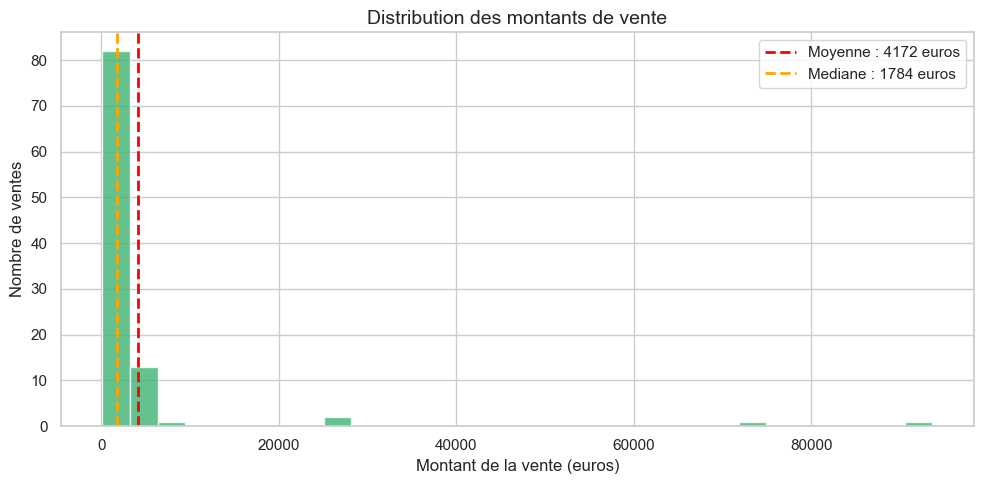

In [7]:
# On trace l'histogramme de la distribution des montants de vente
fig, ax = plt.subplots(figsize=(10, 5))

# ax.hist() trace l'histogramme
# bins = nombre d'intervalles (barres)
ax.hist(df["total"].dropna(), bins=30, color="mediumseagreen", edgecolor="white", alpha=0.8)

# Ligne rouge pour la moyenne, ligne orange pour la mediane
ax.axvline(df["total"].mean(), color="red", linestyle="--", linewidth=2,
           label="Moyenne : " + str(int(df["total"].mean())) + " euros")
ax.axvline(df["total"].median(), color="orange", linestyle="--", linewidth=2,
           label="Mediane : " + str(int(df["total"].median())) + " euros")

ax.set_title("Distribution des montants de vente", fontsize=14)  # titre
ax.set_xlabel("Montant de la vente (euros)")                      # axe X
ax.set_ylabel("Nombre de ventes")                                 # axe Y
ax.legend()     # affiche la legende

plt.tight_layout()
plt.show()

### Analyse de l'histogramme

L'histogramme revele la forme de la distribution des montants de vente.

On voit que la distribution est tres **asymetrique vers la droite** : la grande majorite des ventes
sont petites (moins de 5 000 euros), mais quelques tres grosses ventes tirent la moyenne tres haut.
La ligne rouge (moyenne : 4 173 euros) est bien plus elevee que la ligne orange (mediane : 1 784 euros).
Cela confirme que la **mediane est un meilleur indicateur** du montant typique d'une vente
car elle n'est pas influencee par les quelques commandes exceptionnellement grandes.

---
## PARTIE 4 — Camembert (Pie Chart)

### Qu'est-ce qu'un camembert ?

Le **camembert** montre les **proportions** : comment une totalite se divise en parts.

**Exemple de vie reelle :** un budget familial montre en camembert (loyer 40%, nourriture 25%...).

Chaque tranche represente une categorie, sa taille est proportionnelle a sa part.

**Quand l'utiliser ?** Quand on veut montrer des pourcentages qui s'additionnent a 100%.

### Etape 1 : on prepare les donnees (normalisation des noms)

In [8]:
# On normalise les noms de modes de paiement (certains ont des majuscules differentes)
df["paiement"] = df["paiement"].str.title().str.strip()   # uniformise les noms
paiements = df["paiement"].dropna().value_counts()         # compte chaque mode
print(paiements)

paiement
Carte Bancaire    35
Espèces           18
Mobile Money      15
Virement          15
Paypal            14
Name: count, dtype: int64


### Etape 2 : on trace le camembert avec ax.pie() + plt.show()

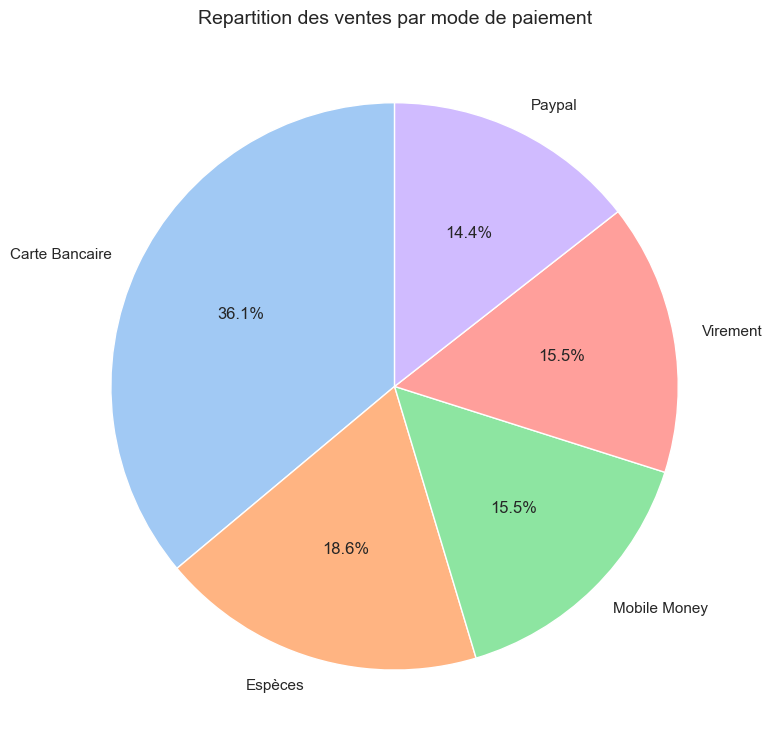

In [9]:
# On cree le camembert de repartition des modes de paiement
fig, ax = plt.subplots(figsize=(8, 8))

# ax.pie() trace le camembert
# autopct affiche le pourcentage sur chaque part
ax.pie(paiements.values,
       labels=paiements.index,        # nom de chaque tranche
       autopct="%1.1f%%",             # affiche "42.3%" sur chaque part
       startangle=90,                 # la premiere tranche commence en haut
       colors=sns.color_palette("pastel"))  # couleurs douces

ax.set_title("Repartition des ventes par mode de paiement", fontsize=14)

plt.tight_layout()
plt.show()

### Analyse du camembert

Ce camembert montre comment les clients de Koryxa paient leurs achats.

On constate que les modes de paiement sont repartis de maniere relativement equilibree :
Carte Bancaire, Especes, Virement, PayPal et Mobile Money representent chacun environ 15 a 25%
des transactions.
Cela signifie que Koryxa doit maintenir **tous ces systemes de paiement** operationnels.
Aucun ne domine assez pour qu'on puisse en supprimer un sans perdre des clients.

---
## PARTIE 5 — Boxplot avec Seaborn

### Qu'est-ce qu'un boxplot ?

Le **boxplot** (boite a moustaches) resume la distribution en 5 valeurs cles :
- La **boite** : contient 50% des donnees (de Q1 a Q3)
- La **ligne** au milieu de la boite : la mediane (valeur du milieu)
- Les **moustaches** : s'etendent jusqu'aux valeurs extremes normales
- Les **points** au-dela des moustaches : valeurs aberrantes (outliers)

**Quand l'utiliser ?** Pour comparer la distribution d'une variable numerique entre plusieurs groupes.

**Exemple de vie reelle :** comparer les salaires dans differents secteurs d'activite.

### On trace le boxplot des ventes par categorie avec sns.boxplot() + plt.show()

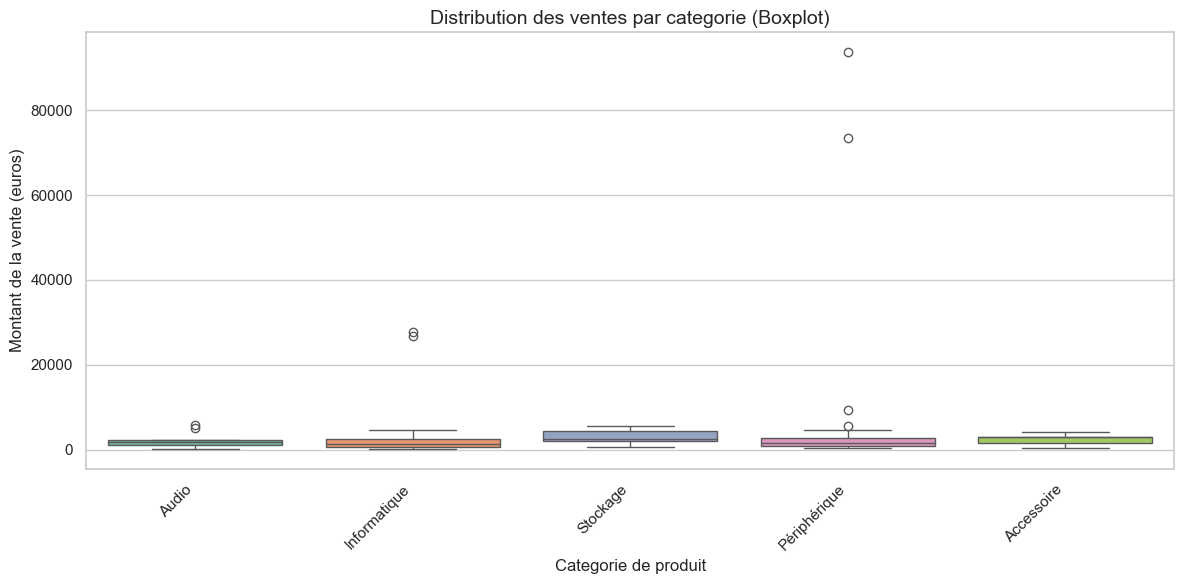

In [10]:
# On trace le boxplot des montants de vente par categorie
fig, ax = plt.subplots(figsize=(12, 6))

# sns.boxplot() trace les boites a moustaches
# x = categorie (axe horizontal), y = valeur numerique (axe vertical)
sns.boxplot(x="categorie", y="total", data=df,
            hue="categorie", palette="Set2", legend=False, ax=ax)

ax.set_title("Distribution des ventes par categorie (Boxplot)", fontsize=14)
ax.set_xlabel("Categorie de produit")        # axe X
ax.set_ylabel("Montant de la vente (euros)") # axe Y
plt.xticks(rotation=45, ha="right")          # incline les etiquettes

plt.tight_layout()
plt.show()

### Analyse du boxplot

Le boxplot permet de comparer la distribution des ventes pour chaque categorie.

La categorie **Informatique** presente la boite la plus haute, ce qui signifie que les montants
varient beaucoup d'une commande a l'autre (grande dispersion).
Les **points isoles** (outliers) au-dessus des moustaches representent des commandes exceptionnellement
grandes — probablement des achats en gros ou des equipements professionnels.
Les categories avec une **mediane elevee** generent des ventes plus importantes en moyenne.

---
## PARTIE 6 — Heatmap (Carte de Chaleur)

### Qu'est-ce qu'une heatmap ?

Une **heatmap** (carte de chaleur) utilise des **couleurs** pour representer des valeurs dans un tableau.

**Exemple de vie reelle :** une carte meteo qui colore les pays selon leur temperature
(rouge = chaud, bleu = froid).

On l'utilise souvent pour la **matrice de correlation** qui montre si deux variables evoluent ensemble :
- Correlation proche de **+1** : les deux augmentent ensemble (rouge)
- Correlation proche de **-1** : quand l'une augmente, l'autre diminue (bleu)
- Correlation proche de **0** : pas de relation (blanc)

**Comment lire une heatmap de correlation ?**
La diagonale est toujours 1.00 (une variable se correle avec elle-meme).
On regarde les cases hors diagonale pour trouver des relations interessantes.

### Etape 1 : on calcule la matrice de correlation

In [11]:
# On calcule la matrice de correlation entre les variables numeriques
colonnes_num = ["age", "quantite", "prix_unitaire", "total", "satisfaction"]
matrice_corr = df[colonnes_num].corr()   # .corr() calcule toutes les correlations

print("Matrice de correlation :")          # affiche le tableau
print(matrice_corr.round(2))              # arrondi a 2 decimales

Matrice de correlation :
                age  quantite  prix_unitaire  total  satisfaction
age            1.00      0.00          -0.12  -0.01         -0.09
quantite       0.00      1.00          -0.00   0.95         -0.09
prix_unitaire -0.12     -0.00           1.00   0.27          0.01
total         -0.01      0.95           0.27   1.00         -0.10
satisfaction  -0.09     -0.09           0.01  -0.10          1.00


### Etape 2 : on visualise avec la heatmap avec sns.heatmap() + plt.show()

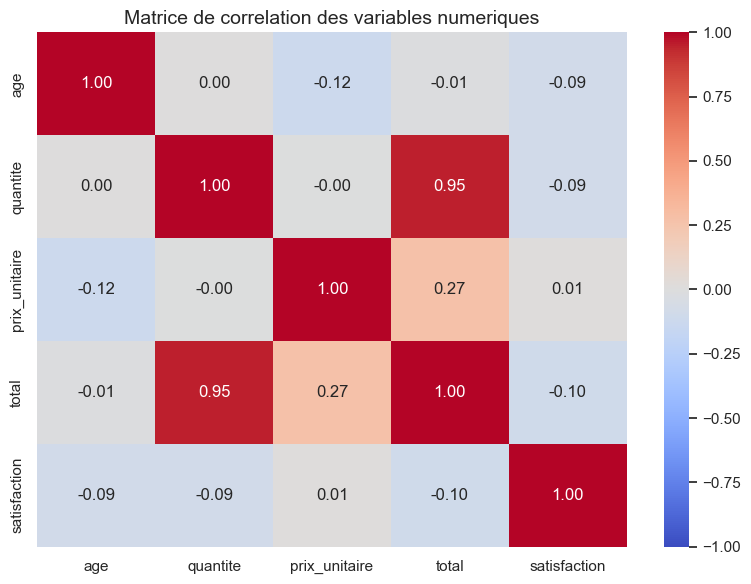

In [12]:
# On trace la heatmap de la matrice de correlation
fig, ax = plt.subplots(figsize=(8, 6))

# sns.heatmap() trace la carte de chaleur
# annot=True affiche les chiffres dans chaque case
# cmap="coolwarm" = bleu pour negatif, rouge pour positif
sns.heatmap(matrice_corr,
            annot=True,        # affiche les valeurs dans les cases
            fmt=".2f",         # format a 2 decimales
            cmap="coolwarm",   # palette de couleurs
            center=0,          # blanc = 0 (pas de correlation)
            vmin=-1, vmax=1,   # echelle de -1 a +1
            ax=ax)

ax.set_title("Matrice de correlation des variables numeriques", fontsize=14)

plt.tight_layout()
plt.show()

### Analyse de la heatmap

La heatmap revele les relations entre toutes les variables numeriques du dataset.

La correlation la plus forte est entre **quantite et total** (0.95, case rouge vif) :
c'est logique — plus on achete d'articles, plus le montant est eleve.
La correlation entre **prix_unitaire et total** est positive mais moderee (0.27).
En revanche, l'**age** et la **satisfaction** ne sont pratiquement pas correlees a quoi que ce soit
(cases presque blanches), ce qui signifie que ces facteurs n'influencent pas le montant des achats.

---
## RECAPITULATIF DU MODULE 5

| Graphique | Commande | Utilisation |
|-----------|----------|-------------|
| Barre | `ax.bar()` | Comparer des categories |
| Courbe | `ax.plot()` | Montrer une evolution dans le temps |
| Histogramme | `ax.hist()` | Distribution d'une variable |
| Camembert | `ax.pie()` | Proportions d'un tout |
| Boxplot | `sns.boxplot()` | Distribution avec statistiques |
| Heatmap | `sns.heatmap()` | Matrice de correlation |

**Regle d'or :** toujours utiliser `%matplotlib inline` en haut du notebook
pour afficher les graphiques directement dans les cellules.

**Dans le prochain module**, on fait une analyse exploratoire complete du dataset !

---
---
# 📖 Ressources — Module 5 : Visualisation de Données

Pour aller plus loin sur Matplotlib et Seaborn, voici 3 ressources en français :

---

### 🔗 1. Guide des visualisations Python avec Seaborn et Matplotlib — MonCoachData.com
**Lien :** https://moncoachdata.com/blog/visualisation-donnees-python/

Guide complet et étape par étape qui couvre les deux bibliothèques.
Parfait pour réviser tous les types de graphiques vus dans ce module.

---

### 🔗 2. Créer ses premiers graphiques avec Matplotlib et Seaborn — Wild Code School
**Lien :** https://www.wildcodeschool.com/fr-FR/blog/premiers-graphiques-matplotlib-seaborn

Syntaxe simple et exemples visuels — parfait pour les débutants.
Bonne référence pour retrouver rapidement comment faire un graphique spécifique.

---

### 🔗 3. Générez des graphiques complexes avec Seaborn — OpenClassrooms
**Lien :** https://openclassrooms.com/fr/courses/7410486-nettoyez-et-analysez-votre-jeu-de-donnees/7571381-generez-des-graphiques-complexes-avec-seaborn

Module dédié avec exercices pratiques sur la plateforme OpenClassrooms.
Tu peux faire les exercices en ligne gratuitement.

---

> 💡 **Conseil :** Un bon graphique doit pouvoir se comprendre **sans texte autour**. Entraîne-toi à ajouter des titres clairs, des labels et une légende à chaque graphique que tu crées.

---
---
# 🎬 Vidéos YouTube — Pour aller plus loin

Ces 2 vidéos en français complètent parfaitement ce module. Regarde-les **après** avoir terminé le notebook pour consolider ce que tu as appris.

---

### 🎥 Vidéo 1 — Initiation à Matplotlib pour la visualisation des données avec Python

**Rechercher sur YouTube :** [Initiation à Matplotlib pour la visualisation des données avec Python](https://www.youtube.com/results?search_query=Initiation%20%C3%A0%20Matplotlib%20pour%20la%20visualisation%20des%20donn%C3%A9es%20avec%20Python)

Courbes, barres, histogrammes et personnalisation des graphiques. Voir le formateur construire les graphiques en direct est beaucoup plus clair que de lire la documentation.

---

### 🎥 Vidéo 2 — Tutoriel Seaborn pour Débutants — Les plus beaux graphiques en une ligne de code

**Rechercher sur YouTube :** [Tutoriel Seaborn pour Débutants — Les plus beaux graphiques en une ligne de code](https://www.youtube.com/results?search_query=Tutoriel%20Seaborn%20pour%20D%C3%A9butants%20%E2%80%94%20Les%20plus%20beaux%20graphiques%20en%20une%20ligne%20de%20code)

Heatmap, boxplot, pairplot avec Seaborn — des graphiques professionnels en très peu de code. La vidéo montre le résultat visuel immédiatement, ce qui aide à choisir le bon graphique.

---

> 💡 **Conseil :** Regarde d'abord le notebook en entier, fais les exercices, **puis** regarde les vidéos. Les vidéos servent à consolider, pas à remplacer la pratique.